Question a)

We need to determine the mean response time for both types of packets from the moment they arrive at the node until they are fully transmitted.

First, we convert the packet sizes from Bytes to bits, given that the link capacity is 1 Mbps ($10^6$ bps).


Expected service time for video packets:
$$E[S_v] = \frac{120 \times 8}{10^6} = 0.00096 \text{ s}$$

\item Expected service time for data packets:
$$E[S_d] = \frac{135 \times 8}{10^6} = 0.00108 \text{ s}$$


Since the packet sizes follow an exponential distribution, the second moment of the service time is twice the square of its expected value:
$$E[S^2] = 2 \cdot (E[S])^2$$

The total traffic load of the system ($/rho$) is the sum of the loads from both flows:
$$\rho = \lambda \cdot E[S_v] + \lambda \cdot E[S_d]$$

Because both flows share the same FIFO queue, they experience the identical mean waiting time ($W$). We calculate this using the Pollaczek-Khinchine (P-K) formula:
$$W = \frac{\lambda \cdot E[S_v^2] + \lambda \cdot E[S_d^2]}{2(1 - \rho)}$$

Finally, the mean response time for each class is the sum of the waiting time and its respective service time:

Mean response time for video flow:
$$T_v = W + E[S_v]$$

Mean response time for data flow:
$$T_d = W + E[S_d]$$


In [1]:
import matplotlib.pyplot as plt

In [ ]:
def calculate_response_times(lambda_rate):
    # System Parameters
    capacity_bps = 1_000_000  # 1 Mbps link capacity
    
    # Calculate expected service times in seconds
    E_Sv = (120 * 8) / capacity_bps  # Video: 120 bytes
    E_Sd = (135 * 8) / capacity_bps  # Data: 135 bytes

    E_Sv_sq = 2 * (E_Sv ** 2)
    E_Sd_sq = 2 * (E_Sd ** 2)
    
    # Calculate Traffic Load 
    # Total load = load from video + load from data
    rho = (lambda_rate * E_Sv) + (lambda_rate * E_Sd)
    
    if rho >= 1:
        return float('inf'), float('inf') # The system crashes if load >= 1
        
    # Calculate Mean Waiting Time (W) using Pollaczek-Khinchine formula
    numerator = lambda_rate * E_Sv_sq + lambda_rate * E_Sd_sq
    denominator = 2 * (1 - rho)
    W = numerator / denominator
    
    #  Calculate Mean Response Time per class
    T_video = W + E_Sv
    T_data = W + E_Sd
    
    return T_video, T_data

In [3]:
# Data preparation for plotting
lambda_values = [300, 325, 350, 375, 400, 425]
response_time_video = []
response_time_data = []

In [4]:
for lam in lambda_values:
    Tv, Td = calculate_response_times(lam)
    # Convert to milliseconds (ms) for a better-looking plot
    response_time_video.append(Tv * 1000)
    response_time_data.append(Td * 1000)

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_43549/3783119253.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Arrival Rate per Flow, $\lambda$ (packets/s)')


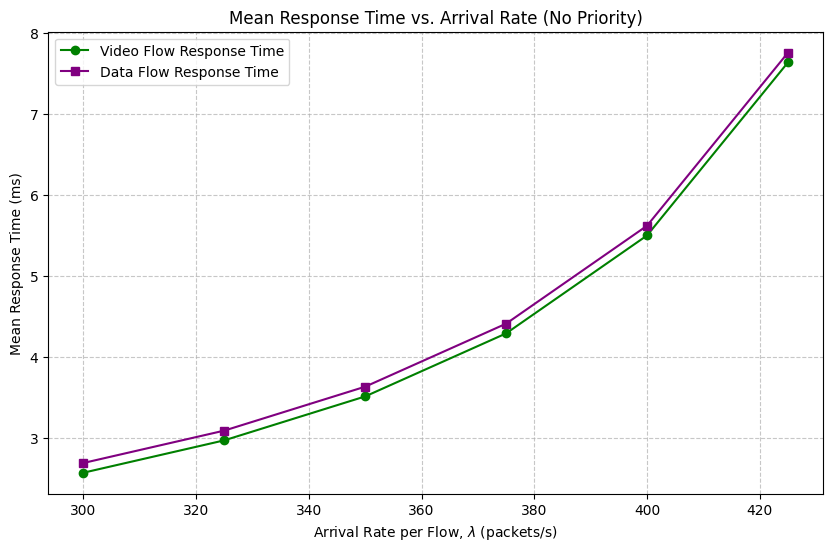

In [5]:
# Plot the graph
plt.figure(figsize=(10, 6))
plt.plot(lambda_values, response_time_video, marker='o', linestyle='-', color='green', label='Video Flow Response Time')
plt.plot(lambda_values, response_time_data, marker='s', linestyle='-', color='purple', label='Data Flow Response Time')

plt.title('Mean Response Time vs. Arrival Rate (No Priority)')
plt.xlabel('Arrival Rate per Flow, $\lambda$ (packets/s)')
plt.ylabel('Mean Response Time (ms)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

As the arrival rate $\lambda$ increases from 300 to 425 packets/s, the mean response times for both video and data flows rise significantly. The curves exhibit an exponential-like growth trend as the total traffic load $\rho$ approaches the link capacity.
Notice that the curves for video and data are completely parallel. The only difference is a small constant offset, which exactly equals the difference in their inherent transmission times (since data packets are slightly larger at 135 bytes vs. 120 bytes). In this FIFO (First-In-First-Out) model, both flows suffer from the exact same queuing delay, regardless of their urgency